Import Libraries:

In [ ]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch import amp
from torch.amp import GradScaler

# Define processed data directory
directory = r"C:\User\projects\Data"

print("PyTorch versão:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())
print("Dispositivo CUDA atual:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Nenhum")

PyTorch versão: 2.9.0+cu128
GPU disponível: True
Dispositivo CUDA atual: NVIDIA GeForce RTX 5070


Load processed data and jump to Training Process:

In [ ]:
# Define input and output sizes, number of input channels and batch size
X_SEQ = 2000
Y_SEQ = 20
INPUT_CHANNELS = 4
BATCH_SIZE = 64

# Define path to npz file
file_path = os.path.join(directory, f"P1_{X_SEQ}_{Y_SEQ}_{INPUT_CHANNELS}.npz")

In [ ]:
# Load compressed file
data = np.load(file_path)

# Extract train, validation and test arrays
X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Convert NumPy array to PyTorch tensor
X_train = torch.from_numpy(X_train.astype(np.float32))
X_val = torch.from_numpy(X_val.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_val = torch.from_numpy(y_val.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

# Wrap data into a TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train shape: (32578, 2000, 4) (32578, 20)
Val shape: (6981, 2000, 4) (6981, 20)
Test shape: (6982, 2000, 4) (6982, 20)


Training Process:

In [ ]:
# Define model
class Conv1DModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(Conv1DModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=INPUT_CHANNELS , out_channels=20, kernel_size=7, padding=(7)//2)  # "same" padding
        self.conv2 = nn.Conv1d(in_channels=20, out_channels=20, kernel_size=7, padding=(7)//2)  # "same" padding
        self.conv3 = nn.Conv1d(in_channels=20, out_channels=20, kernel_size=7, padding=(7)//2)  # "same" padding
        self.conv4 = nn.Conv1d(in_channels=20, out_channels=20, kernel_size=7, padding=(7)//2)  # "same" padding
        self.conv5 = nn.Conv1d(in_channels=20, out_channels=20, kernel_size=7, padding=(7)//2)  # "same" padding
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(20 * input_size, 2048)  # Fully connected layer
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(2048, 1024)  # Fully connected layer
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(1024, output_size)  # Output layer

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Initialize model
model = Conv1DModel(input_size=X_SEQ, output_size=Y_SEQ)
# Model summary
print(model)

Conv1DModel(
  (conv1): Conv1d(4, 20, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(20, 20, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv3): Conv1d(20, 20, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv4): Conv1d(20, 20, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv5): Conv1d(20, 20, kernel_size=(7,), stride=(1,), padding=(3,))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=40000, out_features=2048, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=2048, out_features=1024, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=1024, out_features=20, bias=True)
)


In [ ]:
# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=0.000001, weight_decay=0.000001)  # weight_decay para L2 regularização
criterion = nn.MSELoss()  # Loss function para regressão
scaler = GradScaler()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("\nDispositivo atual:", device)

# Transfer model to VRAM
model = model.to(device)

# Initiate history variables
train_losses, val_losses = [], []


Dispositivo atual: cuda:0


In [ ]:
# Define number of epochs and patience for early stopping
NUM_EPOCHS = 100
patience = 50
best_val_loss = float('inf')
epochs_without_improvement = 0

# Training loop
for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()  # Start epoch timer

    # ----- Training loop -----
    model.train()
    running_train_loss = 0.0
    train_samples = 0

    # tqdm progress bar for training batches
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        with amp.autocast(device_type='cuda'):
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = X_batch.size(0)
        running_train_loss += loss.item() * batch_size
        train_samples += batch_size

    train_loss = running_train_loss / train_samples
    train_losses.append(train_loss)

    # ----- Validation loop -----
    model.eval()
    running_val_loss = 0.0
    val_samples = 0

    for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        with torch.no_grad():
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

        batch_size = X_batch.size(0)
        running_val_loss += loss.item() * batch_size
        val_samples += batch_size

    val_loss = running_val_loss / val_samples
    val_losses.append(val_loss)

    # ----- Time calculations -----
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time  # seconds
    epoch_duration_min = epoch_duration / 60

    # Estimated remaining time
    epochs_done = epoch + 1
    epochs_left = NUM_EPOCHS - epochs_done
    estimated_remaining = epoch_duration * epochs_left
    estimated_remaining_min = estimated_remaining / 60

    # ----- Epoch summary -----
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Time: {epoch_duration_min:.2f} min | "
          f"ETA: {estimated_remaining_min:.2f} min")

    # ----- Early stopping -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pt")  # Save best model
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/100 | Train Loss: 0.4341 | Val Loss: 0.2161 | Time: 0.12 min | ETA: 11.81 min


Epoch 2/100 | Train Loss: 0.1059 | Val Loss: 0.0457 | Time: 0.10 min | ETA: 10.17 min


Epoch 3/100 | Train Loss: 0.0595 | Val Loss: 0.0432 | Time: 0.10 min | ETA: 10.08 min


Epoch 4/100 | Train Loss: 0.0582 | Val Loss: 0.0431 | Time: 0.10 min | ETA: 9.95 min


Epoch 5/100 | Train Loss: 0.0571 | Val Loss: 0.0431 | Time: 0.10 min | ETA: 9.65 min


...

Epoch 96/100 | Train Loss: 0.0047 | Val Loss: 0.0031 | Time: 0.10 min | ETA: 0.39 min


Epoch 97/100 | Train Loss: 0.0047 | Val Loss: 0.0030 | Time: 0.10 min | ETA: 0.29 min


Epoch 98/100 | Train Loss: 0.0046 | Val Loss: 0.0030 | Time: 0.10 min | ETA: 0.21 min


Epoch 99/100 | Train Loss: 0.0047 | Val Loss: 0.0033 | Time: 0.10 min | ETA: 0.10 min


Epoch 100/100 | Train Loss: 0.0046 | Val Loss: 0.0031 | Time: 0.10 min | ETA: 0.00 min


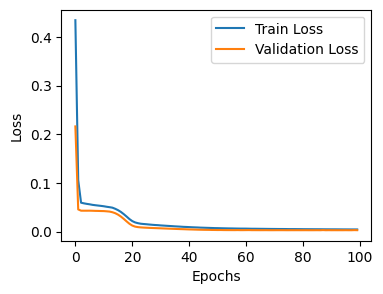

In [ ]:
# Plot loss history
plt.figure(figsize=(4, 3))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Load best weights according to validation loss
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

------------

Make predictions

In [ ]:
# Run model on test set
predictions, ground_truth = [], []

with torch.no_grad():
    model.eval()

    for X_batch, y_batch in test_loader:

        # Transfer batch to VRAM
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        outputs = model(X_batch) # Predictions (shape: [BATCH_SIZE, instances, OUTPUT_SIZE, n_targets])

        # Store predictions and ground truth as tensors
        predictions.append(outputs.cpu())
        ground_truth.append(y_batch.cpu())

# Concatenate all batches
predictions = torch.cat(predictions).numpy()
ground_truth = torch.cat(ground_truth).numpy()

# Example output
print("Predictions shape:", predictions.shape)
print("Ground truth shape:", ground_truth.shape)

Predictions shape: (6982, 20)
Ground truth shape: (6982, 20)


In [ ]:
# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(ground_truth, predictions)
mae = mean_absolute_error(ground_truth, predictions)
rmse = np.sqrt(mse)

# Print metrics
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 0.028323158621788025
Mean Squared Error: 0.0021373445633798838
Root Mean Squared Error: 0.046231423981745186


In [ ]:
# Define function to reconstruct whole signal from predicted output windows
def reconstruct_signal(windows):
    num_instances, timesteps = windows.shape
    reconstructed_length = num_instances + timesteps - 1

    sum_values = np.zeros(reconstructed_length)
    count_values = np.zeros(reconstructed_length)

    for i in range(num_instances):
        sum_values[i:i+timesteps] += windows[i]
        count_values[i:i+timesteps] += 1

    return sum_values / count_values

# Apply function
predictions_rec = reconstruct_signal(predictions)
ground_truth_rec = reconstruct_signal(ground_truth)

Visualização

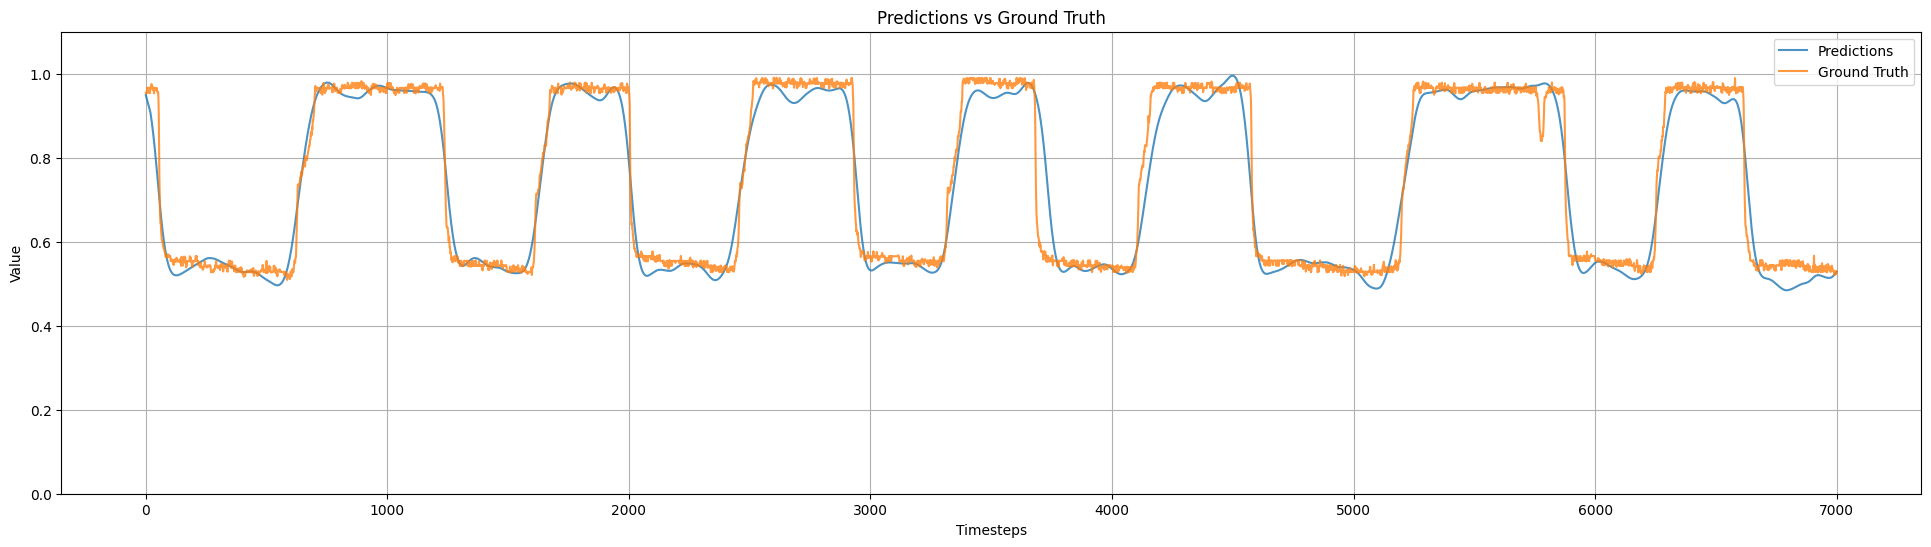

In [ ]:
# Visualize reconstructed signal
pred_subset = predictions_rec[:]
ground_truth_subset = ground_truth_rec[:]

plt.figure(figsize=(24, 6))
plt.plot(pred_subset, label="Predictions", alpha=0.8)
plt.plot(ground_truth_subset, label="Ground Truth", alpha=0.8)
plt.title(f"Predictions vs Ground Truth")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.ylim(0, 1.1)  # Fix y-axis range between 0 and 1
plt.legend()
plt.grid(True)
plt.show()